# AI Precision Oncology

## Notebook 01 – Clinical Data Exploration

### Project
AI Precision Oncology: Interpretable Survival Prediction and Personalized Treatment Recommendation

### Objective

The objective of this notebook is to perform a comprehensive exploratory analysis of the METABRIC Breast Cancer clinical dataset. We will investigate the structure, quality, completeness, and statistical properties of the dataset before developing any machine learning models.

### Dataset

METABRIC Breast Cancer Clinical Dataset

### Developer

Swapnil Anil Kale

### Version

1.0

---

In [1]:
# ============================================================
# Core Python Libraries
# ============================================================

from pathlib import Path
import warnings

# ============================================================
# Data Manipulation
# ============================================================

import numpy as np
import pandas as pd

# ============================================================
# Data Visualization
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Notebook Configuration
# ============================================================

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

plt.style.use("ggplot")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# Project Configuration
# ============================================================

# Random seed for reproducibility
RANDOM_STATE = 42

# Project directories
PROJECT_ROOT = Path.cwd().parent

DATASET_DIR = PROJECT_ROOT / "datasets"
FIGURE_DIR = PROJECT_ROOT / "figures"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

# Create output folders if they do not exist
FIGURE_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# Set NumPy random seed
np.random.seed(RANDOM_STATE)

print("=" * 60)
print("Project Configuration")
print("=" * 60)

print(f"Random Seed : {RANDOM_STATE}")
print(f"Dataset Path: {DATASET_DIR}")
print(f"Figures Path: {FIGURE_DIR}")
print(f"Models Path : {MODEL_DIR}")
print(f"Outputs Path: {OUTPUT_DIR}")

Project Configuration
Random Seed : 42
Dataset Path: e:\Project\AI-Precision-Oncology\datasets
Figures Path: e:\Project\AI-Precision-Oncology\figures
Models Path : e:\Project\AI-Precision-Oncology\models
Outputs Path: e:\Project\AI-Precision-Oncology\outputs


In [3]:
# ============================================================
# Load the METABRIC Clinical Dataset
# ============================================================

DATASET_FILE = DATASET_DIR / "Breast Cancer METABRIC.csv"

# Verify the dataset exists
if not DATASET_FILE.exists():
    raise FileNotFoundError(
        f"Dataset not found at:\n{DATASET_FILE}"
    )

# Load the dataset
df = pd.read_csv(DATASET_FILE)

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)
print(f"Dataset Name : {DATASET_FILE.name}")
print(f"Rows         : {df.shape[0]:,}")
print(f"Columns      : {df.shape[1]}")
print(df.head())

Dataset Loaded Successfully
Dataset Name : Breast Cancer METABRIC.csv
Rows         : 2,509
Columns      : 34
  Patient ID  Age at Diagnosis Type of Breast Surgery    Cancer Type                       Cancer Type Detailed  \
0    MB-0000             75.65             Mastectomy  Breast Cancer           Breast Invasive Ductal Carcinoma   
1    MB-0002             43.19      Breast Conserving  Breast Cancer           Breast Invasive Ductal Carcinoma   
2    MB-0005             48.87             Mastectomy  Breast Cancer           Breast Invasive Ductal Carcinoma   
3    MB-0006             47.68             Mastectomy  Breast Cancer  Breast Mixed Ductal and Lobular Carcinoma   
4    MB-0008             76.97             Mastectomy  Breast Cancer  Breast Mixed Ductal and Lobular Carcinoma   

  Cellularity Chemotherapy Pam50 + Claudin-low subtype  Cohort ER status measured by IHC ER Status  \
0         NaN           No                 claudin-low     1.0                   Positve  Positive

In [4]:
# ============================================================
# Dataset Information
# ============================================================

print("=" * 60)
print("Dataset Information")
print("=" * 60)

df.info()

# ============================================================
# Statistical Summary
# ============================================================

print("=" * 60)
print("Statistical Summary")
print("=" * 60)

df.describe().T

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2509 entries, 0 to 2508
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Patient ID                      2509 non-null   object 
 1   Age at Diagnosis                2498 non-null   float64
 2   Type of Breast Surgery          1955 non-null   object 
 3   Cancer Type                     2509 non-null   object 
 4   Cancer Type Detailed            2509 non-null   object 
 5   Cellularity                     1917 non-null   object 
 6   Chemotherapy                    1980 non-null   object 
 7   Pam50 + Claudin-low subtype     1980 non-null   object 
 8   Cohort                          2498 non-null   float64
 9   ER status measured by IHC       2426 non-null   object 
 10  ER Status                       2469 non-null   object 
 11  Neoplasm Histologic Grade       2388 non-null   float64
 12  HER2 status me

,count,mean,std,min,25%,50%,75%,max
Age at Diagnosis,2498.0,60.420300,13.032997,21.93,50.920000,61.110000,70.000000,96.29
Cohort,2498.0,2.900320,1.962216,1.00,1.000000,3.000000,4.000000,9.00
Neoplasm Histologic Grade,2388.0,2.412060,0.649363,1.00,2.000000,3.000000,3.000000,3.00
Lymph nodes examined positive,2243.0,1.950513,4.017774,0.00,0.000000,0.000000,2.000000,45.00
Mutation Count,2357.0,5.578702,3.967967,1.00,3.000000,5.000000,7.000000,80.00
Nottingham prognostic index,2287.0,4.028787,1.189092,1.00,3.048000,4.044000,5.040000,7.20
Overall Survival (Months),1981.0,125.244271,76.111772,0.00,60.866667,116.466667,185.133333,355.20
Relapse Free Status (Months),2388.0,108.842487,76.519494,0.00,40.560000,99.095000,167.640000,384.21
Tumor Size,2360.0,26.220093,15.370883,1.00,17.000000,22.410000,30.000000,182.00
Tumor Stage,1788.0,1.713647,0.655307,0.00,1.000000,2.000000,2.000000,4.00


In [5]:
# ============================================================
# Missing Value Analysis
# ============================================================

missing_df = (
    pd.DataFrame({
        "Missing Values": df.isnull().sum(),
        "Missing Percentage": (df.isnull().sum() / len(df)) * 100
    })
    .sort_values(by="Missing Percentage", ascending=False)
)

missing_df = missing_df[missing_df["Missing Values"] > 0]

print("=" * 70)
print("Missing Value Summary")
print("=" * 70)

display(missing_df.style.format({"Missing Percentage": "{:.2f}%"}))

Missing Value Summary


,Missing Values,Missing Percentage
3-Gene classifier subtype,745,29.69%
Tumor Stage,721,28.74%
Primary Tumor Laterality,639,25.47%
Cellularity,592,23.60%
Type of Breast Surgery,554,22.08%
Inferred Menopausal State,529,21.08%
Integrative Cluster,529,21.08%
Hormone Therapy,529,21.08%
Pam50 + Claudin-low subtype,529,21.08%
Chemotherapy,529,21.08%


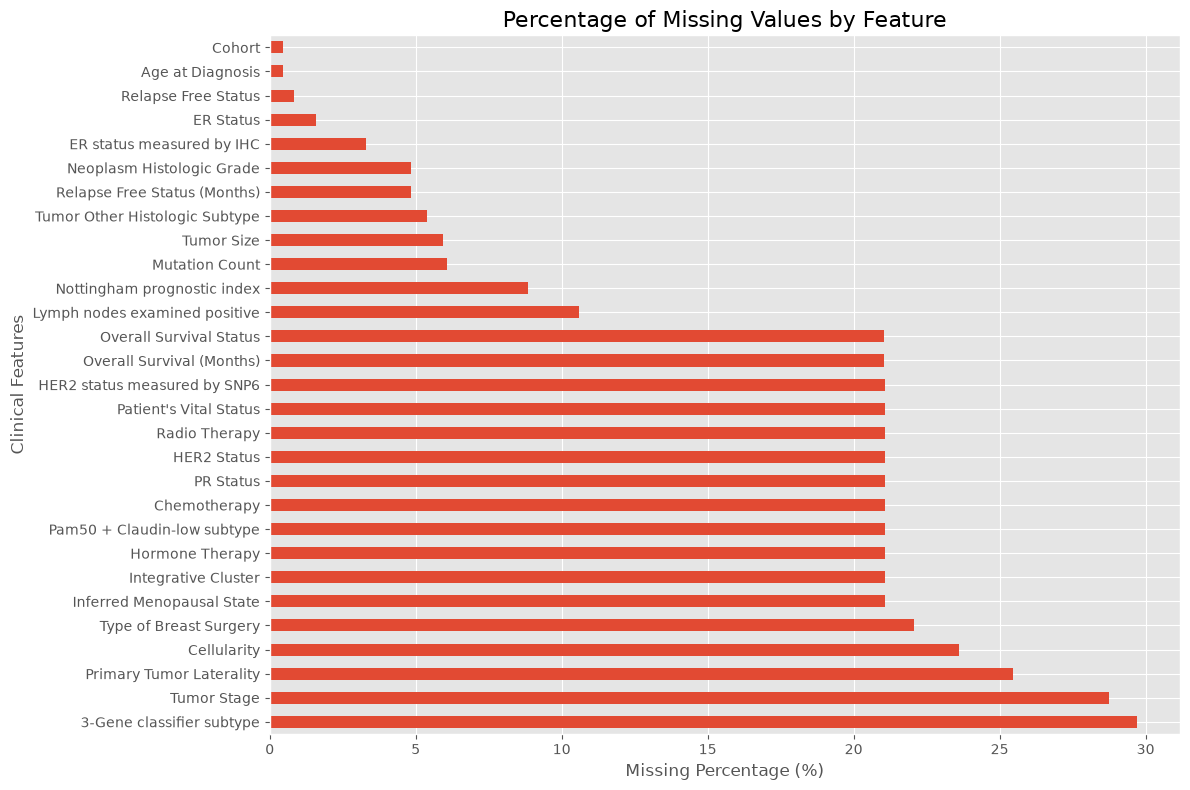

In [6]:
# ============================================================
# Missing Value Visualization
# ============================================================

plt.figure(figsize=(12, 8))

missing_df["Missing Percentage"].plot(kind="barh")

plt.title("Percentage of Missing Values by Feature", fontsize=16)
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Clinical Features")

plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# Identify Numerical and Categorical Features
# ============================================================

numerical_features = df.select_dtypes(include=["number"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object", "string"]).columns.tolist()

print("=" * 70)
print("Feature Summary")
print("=" * 70)

print(f"Total Features      : {df.shape[1]}")
print(f"Numerical Features  : {len(numerical_features)}")
print(f"Categorical Features: {len(categorical_features)}")

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Feature Summary
Total Features      : 34
Numerical Features  : 10
Categorical Features: 24

Numerical Features:
['Age at Diagnosis', 'Cohort', 'Neoplasm Histologic Grade', 'Lymph nodes examined positive', 'Mutation Count', 'Nottingham prognostic index', 'Overall Survival (Months)', 'Relapse Free Status (Months)', 'Tumor Size', 'Tumor Stage']

Categorical Features:
['Patient ID', 'Type of Breast Surgery', 'Cancer Type', 'Cancer Type Detailed', 'Cellularity', 'Chemotherapy', 'Pam50 + Claudin-low subtype', 'ER status measured by IHC', 'ER Status', 'HER2 status measured by SNP6', 'HER2 Status', 'Tumor Other Histologic Subtype', 'Hormone Therapy', 'Inferred Menopausal State', 'Integrative Cluster', 'Primary Tumor Laterality', 'Oncotree Code', 'Overall Survival Status', 'PR Status', 'Radio Therapy', 'Relapse Free Status', 'Sex', '3-Gene classifier subtype', "Patient's Vital Status"]


In [8]:
# ============================================================
# Unique Values in Categorical Variables
# ============================================================

categorical_summary = pd.DataFrame({
    "Unique Values": df[categorical_features].nunique(dropna=True),
    "Missing Values": df[categorical_features].isnull().sum()
}).sort_values(by="Unique Values", ascending=False)

display(categorical_summary)

,Unique Values,Missing Values
Patient ID,2509,0
Integrative Cluster,11,529
Tumor Other Histologic Subtype,8,135
Cancer Type Detailed,8,0
Oncotree Code,8,0
Pam50 + Claudin-low subtype,7,529
HER2 status measured by SNP6,4,529
3-Gene classifier subtype,4,745
Cellularity,3,592
Patient's Vital Status,3,529


In [9]:
# ============================================================
# Frequency Distribution of Key Clinical Variables
# ============================================================

important_features = [
    "ER Status",
    "PR Status",
    "HER2 Status",
    "Chemotherapy",
    "Hormone Therapy",
    "Radio Therapy"
]

for feature in important_features:
    print("\n" + "=" * 70)
    print(feature)
    print("=" * 70)

    print(df[feature].value_counts(dropna=False))


ER Status
ER Status
Positive    1825
Negative     644
NaN           40
Name: count, dtype: int64

PR Status
PR Status
Positive    1040
Negative     940
NaN          529
Name: count, dtype: int64

HER2 Status
HER2 Status
Negative    1733
NaN          529
Positive     247
Name: count, dtype: int64

Chemotherapy
Chemotherapy
No     1568
NaN     529
Yes     412
Name: count, dtype: int64

Hormone Therapy
Hormone Therapy
Yes    1216
No      764
NaN     529
Name: count, dtype: int64

Radio Therapy
Radio Therapy
Yes    1173
No      807
NaN     529
Name: count, dtype: int64


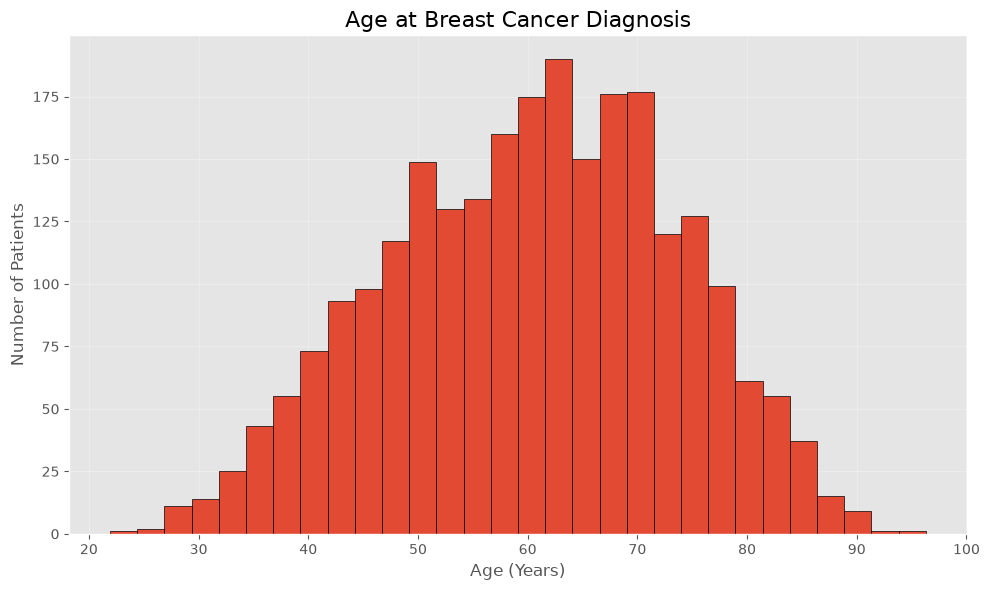

In [10]:
# ============================================================
# Age Distribution
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["Age at Diagnosis"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Age at Breast Cancer Diagnosis", fontsize=16)
plt.xlabel("Age (Years)")
plt.ylabel("Number of Patients")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

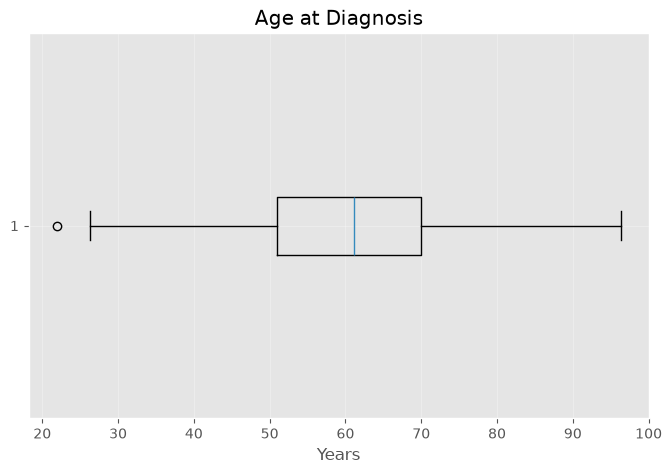

In [11]:
# ============================================================
# Age Box Plot
# ============================================================

plt.figure(figsize=(8, 5))

plt.boxplot(
    df["Age at Diagnosis"].dropna(),
    vert=False
)

plt.title("Age at Diagnosis")

plt.xlabel("Years")

plt.grid(alpha=0.3)

plt.show()

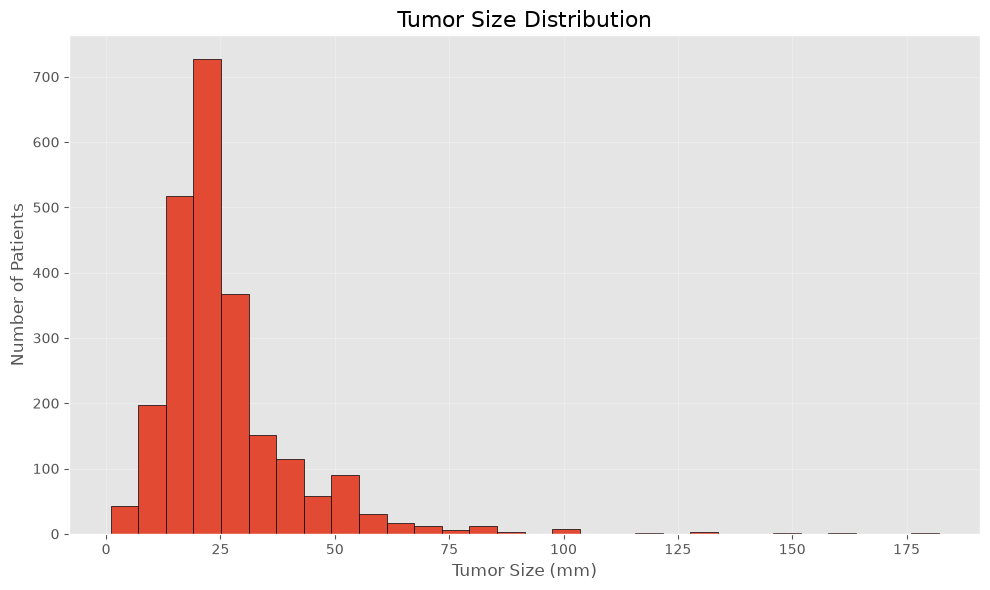

In [12]:
# ============================================================
# Tumor Size Distribution
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["Tumor Size"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Tumor Size Distribution", fontsize=16)
plt.xlabel("Tumor Size (mm)")
plt.ylabel("Number of Patients")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# Correlation Matrix of Numerical Features
# ============================================================

# Compute Pearson correlation matrix
correlation_matrix = df[numerical_features].corr(method="pearson")

# Display rounded values
display(correlation_matrix.round(2))

,Age at Diagnosis,Cohort,Neoplasm Histologic Grade,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Overall Survival (Months),Relapse Free Status (Months),Tumor Size,Tumor Stage
Age at Diagnosis,1.00,-0.06,-0.12,-0.01,0.03,-0.10,-0.15,-0.10,0.06,0.07
Cohort,-0.06,1.00,-0.05,0.00,0.08,-0.13,0.09,0.03,-0.02,-0.06
Neoplasm Histologic Grade,-0.12,-0.05,1.00,0.15,0.05,0.70,-0.13,-0.11,0.14,0.19
Lymph nodes examined positive,-0.01,0.00,0.15,1.00,-0.04,0.55,-0.24,-0.23,0.27,0.44
Mutation Count,0.03,0.08,0.05,-0.04,1.00,0.00,0.04,0.03,0.02,-0.02
Nottingham prognostic index,-0.10,-0.13,0.70,0.55,0.00,1.00,-0.24,-0.20,0.29,0.55
Overall Survival (Months),-0.15,0.09,-0.13,-0.24,0.04,-0.24,1.00,0.90,-0.19,-0.27
Relapse Free Status (Months),-0.10,0.03,-0.11,-0.23,0.03,-0.20,0.90,1.00,-0.19,-0.23
Tumor Size,0.06,-0.02,0.14,0.27,0.02,0.29,-0.19,-0.19,1.00,0.49
Tumor Stage,0.07,-0.06,0.19,0.44,-0.02,0.55,-0.27,-0.23,0.49,1.00


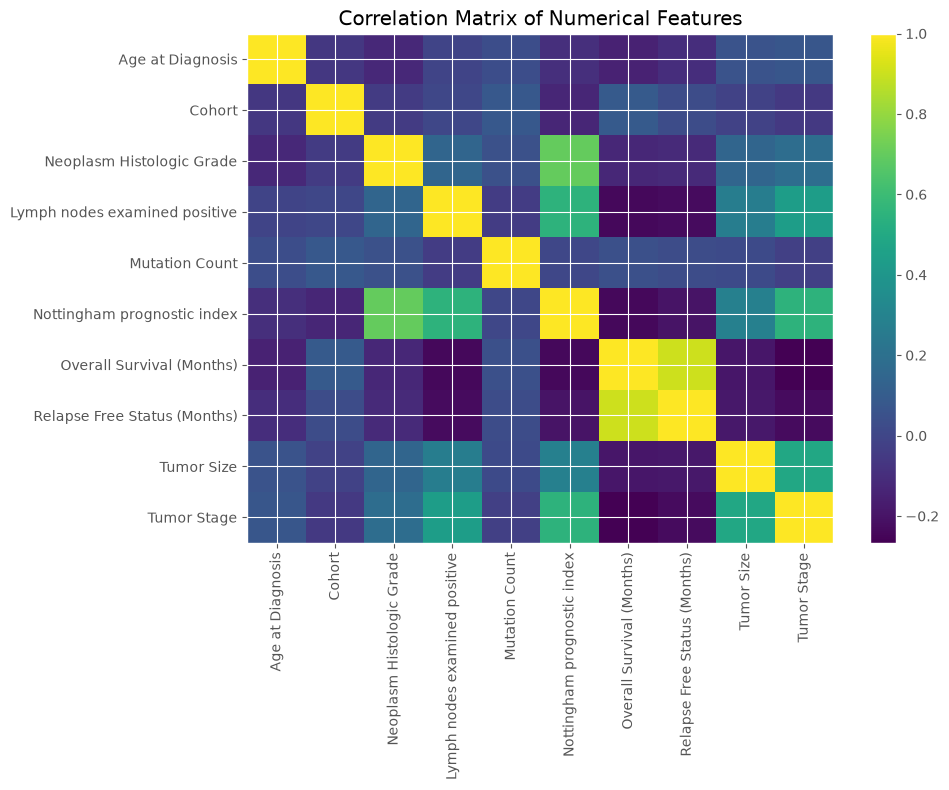

In [14]:
# ============================================================
# Correlation Heatmap
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(correlation_matrix, aspect="auto")

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=90)

ax.set_yticks(range(len(correlation_matrix.columns)))
ax.set_yticklabels(correlation_matrix.columns)

fig.colorbar(im, ax=ax)

ax.set_title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

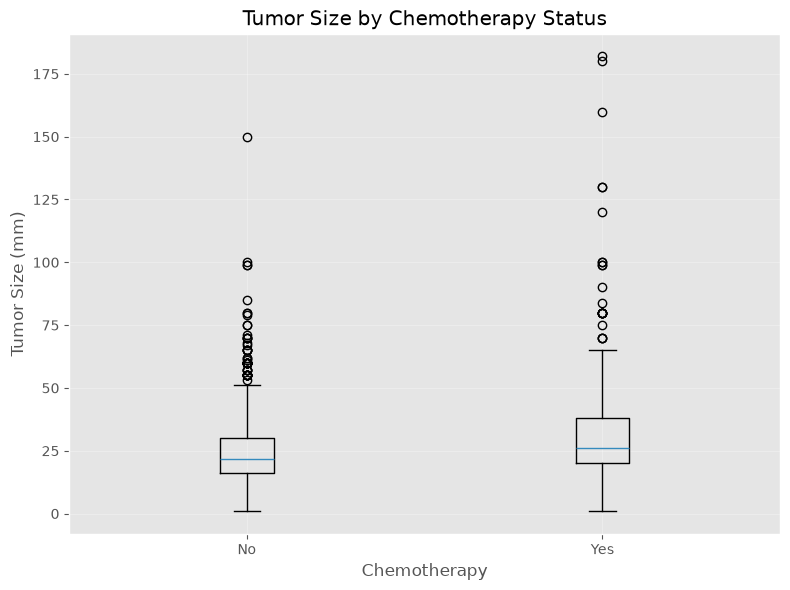

In [15]:
# ============================================================
# Tumor Size vs Chemotherapy
# ============================================================

# Remove rows with missing values for this comparison
chemo_df = df[["Tumor Size", "Chemotherapy"]].dropna()

fig, ax = plt.subplots(figsize=(8, 6))

groups = [
    chemo_df.loc[chemo_df["Chemotherapy"] == "No", "Tumor Size"],
    chemo_df.loc[chemo_df["Chemotherapy"] == "Yes", "Tumor Size"]
]

ax.boxplot(
    groups,
    tick_labels=["No", "Yes"]
)

ax.set_title("Tumor Size by Chemotherapy Status")
ax.set_xlabel("Chemotherapy")
ax.set_ylabel("Tumor Size (mm)")

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# Tumor Size Summary by Chemotherapy
# ============================================================

tumor_summary = (
    chemo_df
    .groupby("Chemotherapy")["Tumor Size"]
    .describe()
)

display(tumor_summary.round(2))

,count,mean,std,min,25%,50%,75%,max
Chemotherapy,,,,,,,,
No,1548.0,24.70,12.59,1.0,16.0,21.8,30.0,150.0
Yes,406.0,32.29,22.12,1.0,20.0,26.0,38.0,182.0


In [17]:
# ============================================================
# Mann–Whitney U Test
# ============================================================

from scipy.stats import mannwhitneyu

tumor_no = chemo_df.loc[
    chemo_df["Chemotherapy"] == "No",
    "Tumor Size"
]

tumor_yes = chemo_df.loc[
    chemo_df["Chemotherapy"] == "Yes",
    "Tumor Size"
]

statistic, p_value = mannwhitneyu(
    tumor_no,
    tumor_yes,
    alternative="two-sided"
)

print("=" * 60)
print("Mann–Whitney U Test")
print("=" * 60)
print(f"U Statistic : {statistic:.2f}")
print(f"P-value     : {p_value:.6f}")

Mann–Whitney U Test
U Statistic : 238301.50
P-value     : 0.000000


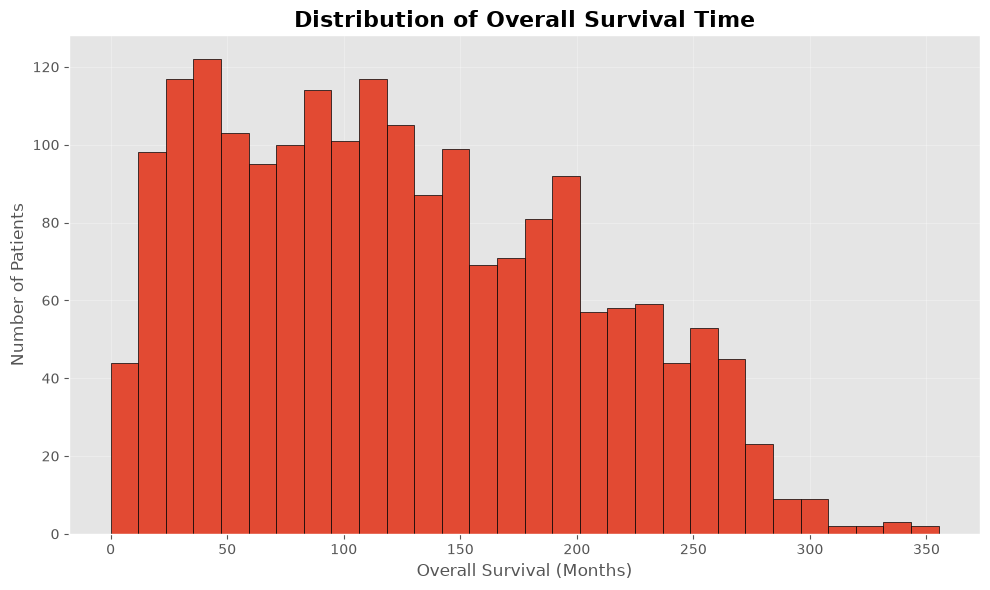

In [18]:
# ============================================================
# Overall Survival Distribution
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

survival = df["Overall Survival (Months)"].dropna()

ax.hist(
    survival,
    bins=30,
    edgecolor="black"
)

ax.set_title(
    "Distribution of Overall Survival Time",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Overall Survival (Months)")
ax.set_ylabel("Number of Patients")

ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "overall_survival_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

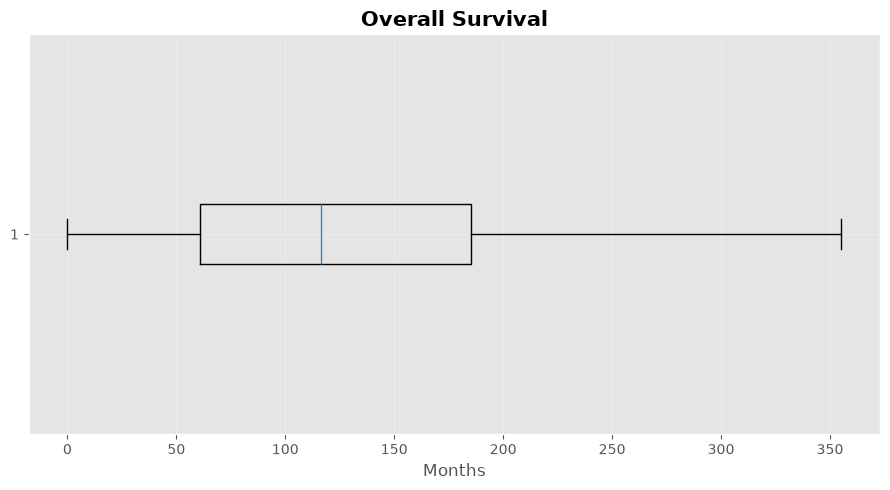

In [19]:
# ============================================================
# Overall Survival Box Plot
# ============================================================

fig, ax = plt.subplots(figsize=(9,5))

ax.boxplot(
    survival,
    vert=False
)

ax.set_title(
    "Overall Survival",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Months")

ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "overall_survival_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

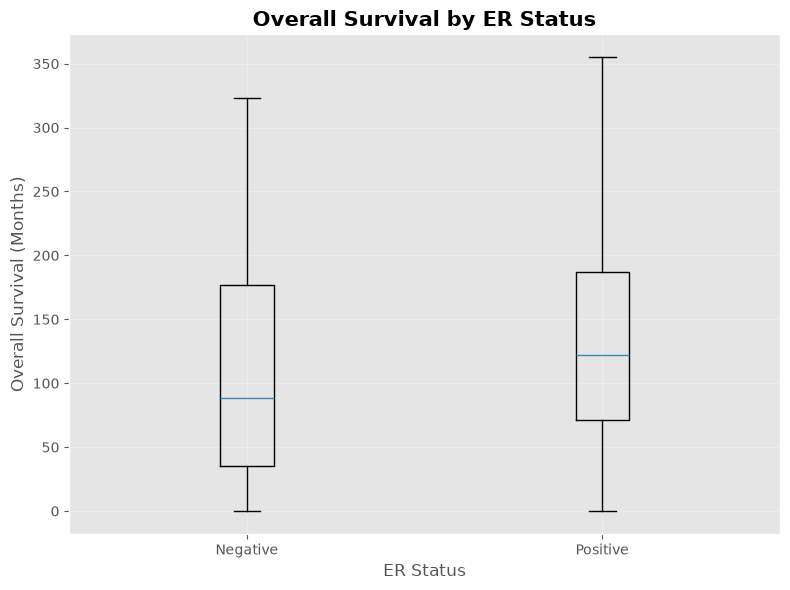

In [20]:
# ============================================================
# Overall Survival by ER Status
# ============================================================

survival_er = df[
    ["ER Status", "Overall Survival (Months)"]
].dropna()

groups = [
    survival_er.loc[
        survival_er["ER Status"] == "Negative",
        "Overall Survival (Months)"
    ],
    survival_er.loc[
        survival_er["ER Status"] == "Positive",
        "Overall Survival (Months)"
    ]
]

fig, ax = plt.subplots(figsize=(8,6))

ax.boxplot(
    groups,
    tick_labels=["Negative", "Positive"]
)

ax.set_title(
    "Overall Survival by ER Status",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("ER Status")
ax.set_ylabel("Overall Survival (Months)")

ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "survival_by_er_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
# ============================================================
# Survival Summary by ER Status
# ============================================================

summary = (
    survival_er
    .groupby("ER Status")
    ["Overall Survival (Months)"]
    .describe()
)

display(summary.round(2))

,count,mean,std,min,25%,50%,75%,max
ER Status,,,,,,,,
Negative,474.0,108.31,81.23,0.0,35.29,88.53,176.63,322.83
Positive,1507.0,130.57,73.65,0.1,71.50,122.20,186.73,355.20


In [22]:
# ============================================================
# Mann–Whitney U Test
# ============================================================

from scipy.stats import mannwhitneyu

negative = survival_er.loc[
    survival_er["ER Status"] == "Negative",
    "Overall Survival (Months)"
]

positive = survival_er.loc[
    survival_er["ER Status"] == "Positive",
    "Overall Survival (Months)"
]

u, p = mannwhitneyu(
    negative,
    positive,
    alternative="two-sided"
)

print("=" * 60)
print("ER Status vs Overall Survival")
print("=" * 60)

print(f"U Statistic : {u:.2f}")
print(f"P-value     : {p:.6f}")

alpha = 0.05

if p < alpha:
    print("\nConclusion:")
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in overall survival between ER-positive and ER-negative patients.")
else:
    print("\nConclusion:")
    print("Fail to reject the null hypothesis.")
    print("No statistically significant difference in overall survival was detected.")

ER Status vs Overall Survival
U Statistic : 289138.50
P-value     : 0.000000

Conclusion:
Reject the null hypothesis.
There is a statistically significant difference in overall survival between ER-positive and ER-negative patients.


In [23]:
import lifelines

print(lifelines.__version__)
# ============================================================
# Survival Analysis Libraries
# ============================================================

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

print("Lifelines imported successfully.")
# ============================================================
# Inspect Overall Survival Status
# ============================================================

print("=" * 60)
print("Overall Survival Status")
print("=" * 60)

print(df["Overall Survival Status"].value_counts(dropna=False))

print("\n" + "=" * 60)
print("Patient's Vital Status")
print("=" * 60)

print(df["Patient's Vital Status"].value_counts(dropna=False))
df["Overall Survival Status"].value_counts(dropna=False)
df["Patient's Vital Status"].value_counts(dropna=False)

0.30.3
Lifelines imported successfully.
Overall Survival Status
Overall Survival Status
Deceased    1144
Living       837
NaN          528
Name: count, dtype: int64

Patient's Vital Status
Patient's Vital Status
Living                  837
Died of Disease         646
NaN                     529
Died of Other Causes    497
Name: count, dtype: int64


Patient's Vital Status
Living                  837
Died of Disease         646
NaN                     529
Died of Other Causes    497
Name: count, dtype: int64

In [24]:
# ============================================================
# Prepare Survival Analysis Dataset
# ============================================================

survival_df = df[
    [
        "Overall Survival (Months)",
        "Overall Survival Status",
        "ER Status"
    ]
].copy()

# Remove missing observations
survival_df = survival_df.dropna()

# Convert survival status to event indicator
survival_df["Event"] = (
    survival_df["Overall Survival Status"]
    .map({
        "Living": 0,
        "Deceased": 1
    })
)

print("=" * 60)
print("Survival Dataset")
print("=" * 60)

print(survival_df.head())

print("\nShape:", survival_df.shape)

Survival Dataset
   Overall Survival (Months) Overall Survival Status ER Status  Event
0                 140.500000                  Living  Positive      0
1                  84.633333                  Living  Positive      0
2                 163.700000                Deceased  Positive      1
3                 164.933333                  Living  Positive      0
4                  41.366667                Deceased  Positive      1

Shape: (1981, 4)


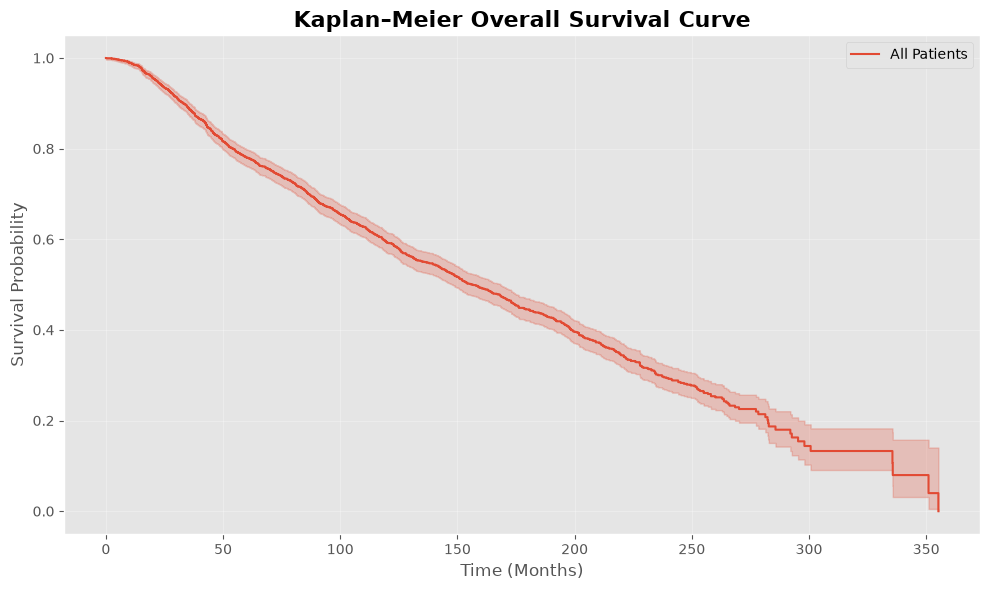

In [25]:
# ============================================================
# Kaplan–Meier Survival Curve
# ============================================================

kmf = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(10, 6))

kmf.fit(
    durations=survival_df["Overall Survival (Months)"],
    event_observed=survival_df["Event"],
    label="All Patients"
)

kmf.plot_survival_function(ax=ax)

ax.set_title(
    "Kaplan–Meier Overall Survival Curve",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Time (Months)")
ax.set_ylabel("Survival Probability")

ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "kaplan_meier_overall_survival.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
# ============================================================
# Median Survival Time
# ============================================================

print("=" * 60)
print("Median Overall Survival")
print("=" * 60)

print(f"{kmf.median_survival_time_:.2f} months")

Median Overall Survival
156.33 months


In [27]:
# ============================================================
# Survival Table
# ============================================================

kmf.survival_function_.head(15)

,All Patients
timeline,
0.000000,1.000000
0.100000,0.999495
0.766667,0.999495
1.233333,0.999495
1.266667,0.999495
1.433333,0.999495
1.766667,0.999495
2.000000,0.999495
2.300000,0.998988
